# SEA-Net - data analysis

A simple, read-only look at the three files SEA-Net writes:

- `results/SEA_NET/data_summary.csv` - one row per dataset (sizes, length, #classes, class balance)
- `results/SEA_NET/results.csv` - SEA-Net's metrics per dataset (accuracy, AOPCR, NDCG, params)
- `results/SEA_NET/comparison_vs_millet.csv` - SEA-Net vs the MILLET baseline (win/tie/loss)

It only reads and plots - it trains nothing. Run it any time; it shows whatever has finished so far.
Figures are also saved to `results/SEA_NET/figures/`.

In [1]:
import os, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Find the repo root (the folder that contains the "seanet" package) and make it importable.
root = Path.cwd()
while root != root.parent and not (root / "seanet" / "__init__.py").exists():
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from seanet import data as D
from seanet import results as R

FIGDIR = os.path.join("results", "SEA_NET", "figures")
os.makedirs(FIGDIR, exist_ok=True)

def to_num(df, cols):
    """Make sure the given columns are numbers (the CSVs can have stray spaces)."""
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

print("repo root:", root)

repo root: d:\Documents\Intership TSC\Projects\SEA-NET\MILTimeSeriesClassification


## 1. Dataset summary

What the datasets look like: series length, number of classes, train size, and how many needed the cleaned "adjusted" folder.

In [2]:
summary = D.read_our_csv(D.DATA_SUMMARY_CSV)
summary = to_num(summary, ["n_train", "n_test", "series_length", "n_classes", "imbalance_ratio"])
print("datasets summarised:", len(summary))
summary.head()

datasets summarised: 133


,dataset,source,used_adjusted_folder,n_train,n_test,series_length,n_classes,train_class_counts,min_class_frac,max_class_frac,imbalance_ratio,train_raw_nan,test_raw_nan,sanity_ok
0,DodgerLoopDay,UCR,True,78,80,288,7,12 10 10 11 12 12 11,0.1282,0.1538,1.20,0,0,True
1,PLAID,UCR,True,537,537,1344,11,33 88 57 19 78 18 57 86 69 19 13,0.0242,0.1639,6.77,0,0,True
2,ArrowHead,UCR,False,36,175,251,3,12 12 12,0.3333,0.3333,1.00,0,0,True
3,WebTraffic,WebTraffic,False,500,500,1008,10,50 50 50 50 50 50 50 50 50 50,0.1000,0.1000,1.00,0,0,True
4,Coffee,UCR,False,28,28,286,2,14 14,0.5000,0.5000,1.00,0,0,True


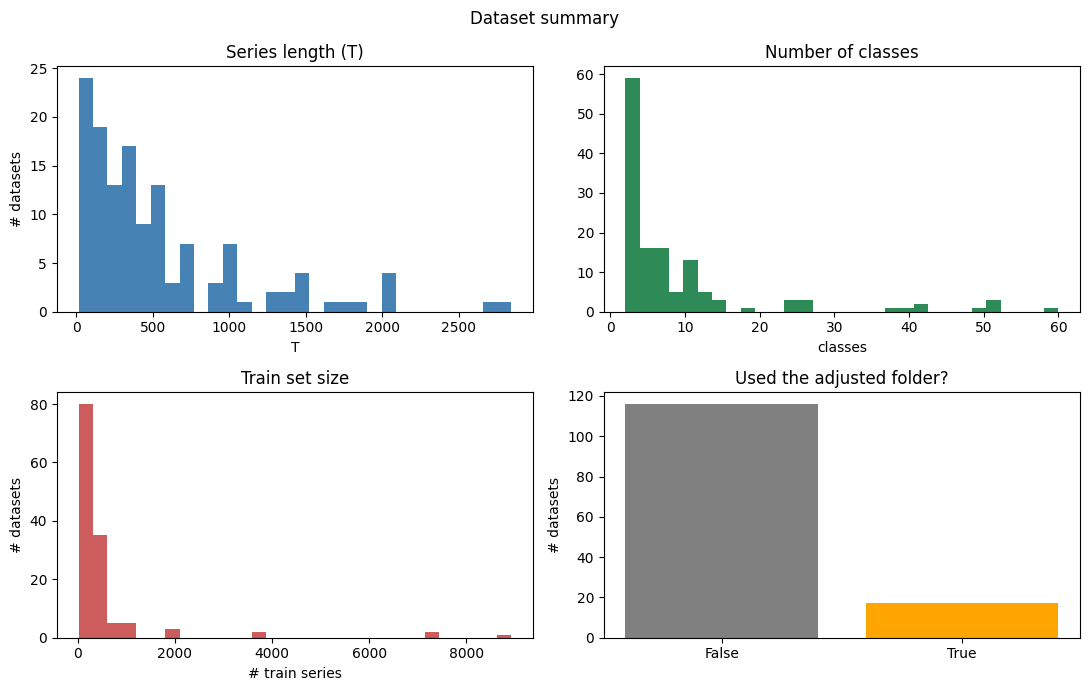

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

ax[0, 0].hist(summary["series_length"].dropna(), bins=30, color="steelblue")
ax[0, 0].set_title("Series length (T)"); ax[0, 0].set_xlabel("T"); ax[0, 0].set_ylabel("# datasets")

ax[0, 1].hist(summary["n_classes"].dropna(), bins=30, color="seagreen")
ax[0, 1].set_title("Number of classes"); ax[0, 1].set_xlabel("classes")

ax[1, 0].hist(summary["n_train"].dropna(), bins=30, color="indianred")
ax[1, 0].set_title("Train set size"); ax[1, 0].set_xlabel("# train series"); ax[1, 0].set_ylabel("# datasets")

counts = summary["used_adjusted_folder"].astype(str).value_counts()
ax[1, 1].bar(counts.index, counts.values, color=["gray", "orange"])
ax[1, 1].set_title("Used the adjusted folder?"); ax[1, 1].set_ylabel("# datasets")

fig.suptitle("Dataset summary"); fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "data_summary.png"), dpi=120)
plt.show()

## 2. SEA-Net results

SEA-Net's own numbers per dataset. Accuracy is classification quality; AOPCR is interpretation faithfulness (higher = better); NDCG exists only for WebTraffic. The model size is the same for every dataset.

In [4]:
res = R.load_results()
res = to_num(res, ["test_acc", "test_aopcr", "test_ndcg", "series_length", "n_classes",
                   "params", "model_size_mb", "train_time_s"])
print("datasets with results:", len(res))
if len(res):
    print("mean test accuracy :", round(res["test_acc"].mean(), 4))
    print("mean AOPCR         :", round(res["test_aopcr"].mean(), 4))
    print("params / size MB   :", int(res["params"].iloc[0]), "/", round(res["model_size_mb"].iloc[0], 3))
res[["dataset", "test_acc", "test_aopcr", "test_ndcg", "train_time_s"]].head()

datasets with results: 129
mean test accuracy : 0.8296
mean AOPCR         : 0.6585
params / size MB   : 269083 / 3.539


,dataset,test_acc,test_aopcr,test_ndcg,train_time_s
0,WebTraffic,0.9580,1.4730,0.7133,620.86
1,ACSF1,0.7900,0.0864,NaN,76.93
2,Adiac,0.7724,0.1380,NaN,438.49
3,AllGestureWiimoteX,0.7643,1.9419,NaN,296.08
4,AllGestureWiimoteY,0.8171,1.6736,NaN,349.63


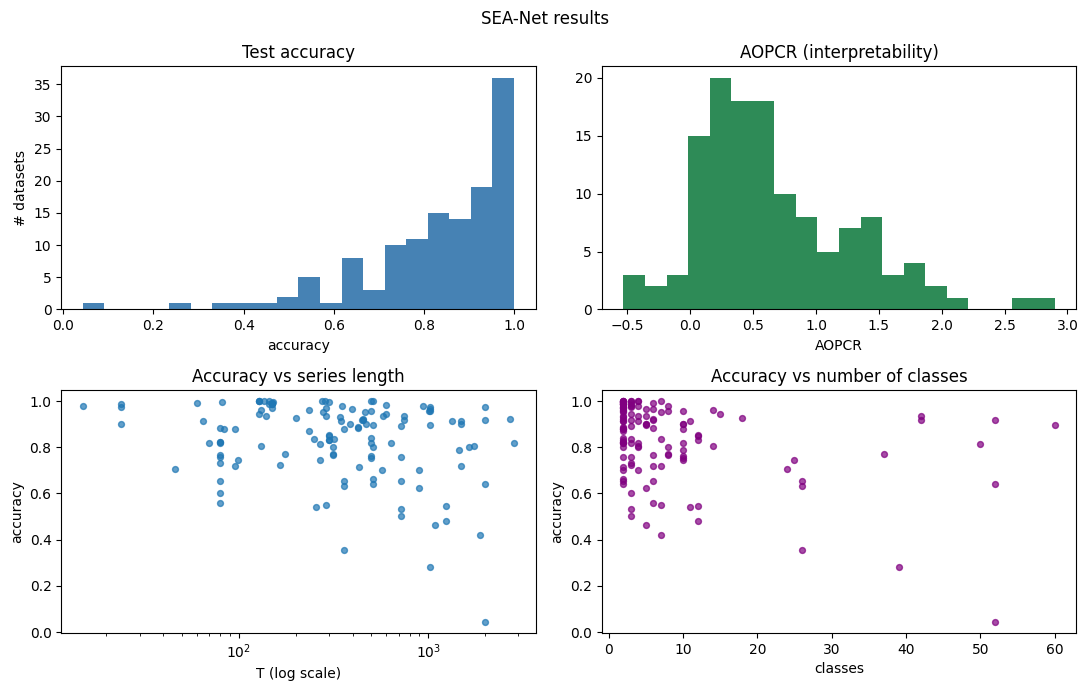

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

ax[0, 0].hist(res["test_acc"].dropna(), bins=20, color="steelblue")
ax[0, 0].set_title("Test accuracy"); ax[0, 0].set_xlabel("accuracy"); ax[0, 0].set_ylabel("# datasets")

ax[0, 1].hist(res["test_aopcr"].dropna(), bins=20, color="seagreen")
ax[0, 1].set_title("AOPCR (interpretability)"); ax[0, 1].set_xlabel("AOPCR")

ax[1, 0].scatter(res["series_length"], res["test_acc"], s=18, alpha=0.7)
ax[1, 0].set_xscale("log")
ax[1, 0].set_title("Accuracy vs series length"); ax[1, 0].set_xlabel("T (log scale)"); ax[1, 0].set_ylabel("accuracy")

ax[1, 1].scatter(res["n_classes"], res["test_acc"], s=18, alpha=0.7, color="purple")
ax[1, 1].set_title("Accuracy vs number of classes"); ax[1, 1].set_xlabel("classes"); ax[1, 1].set_ylabel("accuracy")

fig.suptitle("SEA-Net results"); fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "results.png"), dpi=120)
plt.show()

## 3. Comparison vs MILLET

For the datasets that overlap the MILLET paper (85 of the 128), compare SEA-Net to MILLET's InceptionTime+Conjunctive baseline. In the scatter plots, a point **above the red y=x line means SEA-Net wins**.

In [6]:
cmp = R.build_comparison(verbose=False)      # rebuilds comparison_vs_millet.csv from current results
cmp = to_num(cmp, ["ours_acc", "millet_acc", "acc_diff", "ours_aopcr", "millet_aopcr", "aopcr_diff"])
overlap = cmp[cmp["acc_outcome"] != "no_baseline"].copy()   # only datasets with a MILLET baseline

print("UCR datasets evaluated:", len(cmp), "| with a MILLET baseline:", len(overlap))
print("accuracy win/tie/loss:", overlap["acc_outcome"].value_counts().to_dict())
print("AOPCR    win/tie/loss:", overlap["aopcr_outcome"].value_counts().to_dict())
if len(overlap):
    print("mean acc  : ours", round(overlap["ours_acc"].mean(), 4), "vs MILLET", round(overlap["millet_acc"].mean(), 4))
    print("mean AOPCR: ours", round(overlap["ours_aopcr"].mean(), 3), "vs MILLET", round(overlap["millet_aopcr"].mean(), 3))
overlap[["dataset", "ours_acc", "millet_acc", "acc_outcome", "ours_aopcr", "millet_aopcr", "aopcr_outcome"]].head(10)

UCR datasets evaluated: 128 | with a MILLET baseline: 85
accuracy win/tie/loss: {'loss': 45, 'win': 26, 'tie': 14}
AOPCR    win/tie/loss: {'loss': 81, 'win': 4}
mean acc  : ours 0.8294 vs MILLET 0.8445
mean AOPCR: ours 0.572 vs MILLET 4.553


,dataset,ours_acc,millet_acc,acc_outcome,ours_aopcr,millet_aopcr,aopcr_outcome
0,Adiac,0.7724,0.8317,loss,0.1380,15.8906,loss
1,ArrowHead,0.8343,0.8377,tie,0.2312,3.2005,loss
2,Beef,0.9000,0.8467,win,1.0665,5.4866,loss
3,BeetleFly,0.8000,0.9200,loss,-0.0102,1.2424,loss
4,BirdChicken,1.0000,0.9400,win,0.4916,3.3665,loss
5,Car,0.9333,0.9200,win,0.5295,6.6173,loss
6,CBF,1.0000,0.9998,tie,0.1978,3.5827,loss
7,ChlorineConcentration,0.7214,0.8576,loss,0.2344,2.1418,loss
8,CinCECGTorso,0.8029,0.8239,loss,0.8857,4.7745,loss
9,Coffee,1.0000,1.0000,tie,0.3925,3.4889,loss


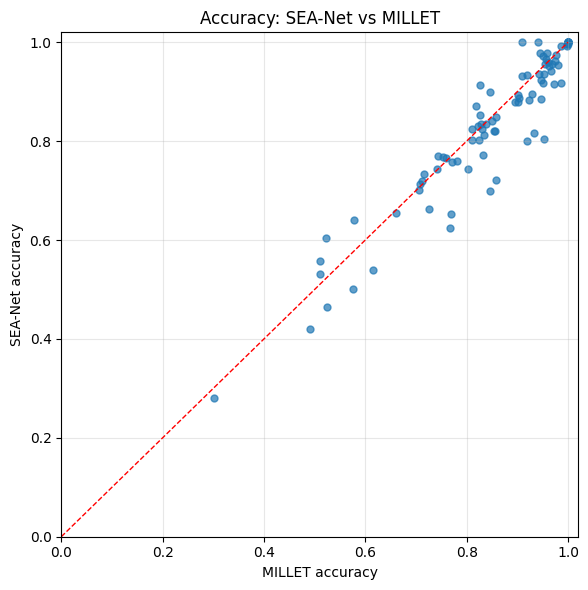

In [7]:
# Accuracy: SEA-Net vs MILLET (a point ABOVE the red line = SEA-Net wins)
plt.figure(figsize=(6, 6))
plt.scatter(overlap["millet_acc"], overlap["ours_acc"], s=25, alpha=0.7)
plt.plot([0, 1], [0, 1], "r--", lw=1)
plt.xlabel("MILLET accuracy"); plt.ylabel("SEA-Net accuracy")
plt.title("Accuracy: SEA-Net vs MILLET")
plt.xlim(0, 1.02); plt.ylim(0, 1.02); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, "acc_scatter.png"), dpi=120)
plt.show()

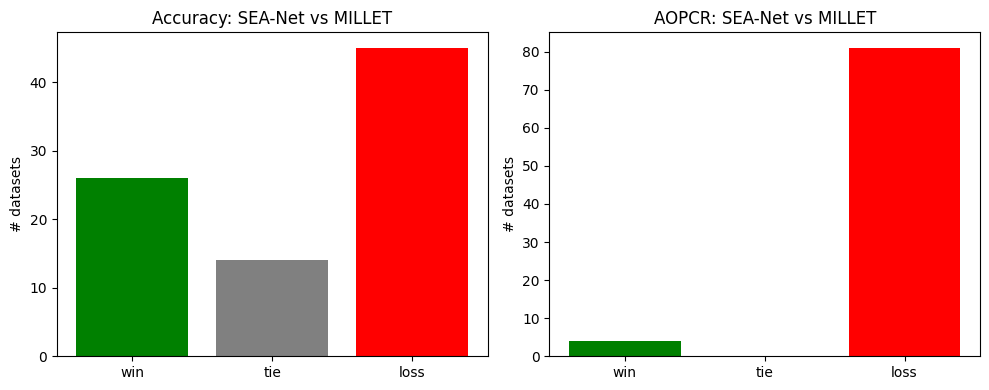

In [8]:
# Win / tie / loss counts, for accuracy and for AOPCR
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, col, title in [(ax[0], "acc_outcome", "Accuracy"), (ax[1], "aopcr_outcome", "AOPCR")]:
    vc = overlap[col].value_counts().reindex(["win", "tie", "loss"]).fillna(0)
    a.bar(vc.index, vc.values, color=["green", "gray", "red"])
    a.set_title(title + ": SEA-Net vs MILLET"); a.set_ylabel("# datasets")
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, "win_tie_loss.png"), dpi=120)
plt.show()

In [ ]:
# # AOPCR: SEA-Net vs MILLET (a point ABOVE the red line = SEA-Net wins)
# plt.figure(figsize=(6, 6))
# lim = max(overlap["millet_aopcr"].max(), overlap["ours_aopcr"].max()) * 1.05
# plt.scatter(overlap["millet_aopcr"], overlap["ours_aopcr"], s=25, alpha=0.7, color="seagreen")
# plt.plot([0, lim], [0, lim], "r--", lw=1)
# plt.xlabel("MILLET AOPCR"); plt.ylabel("SEA-Net AOPCR")
# plt.title("AOPCR: SEA-Net vs MILLET")
# plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, "aopcr_scatter.png"), dpi=120)
# plt.show()

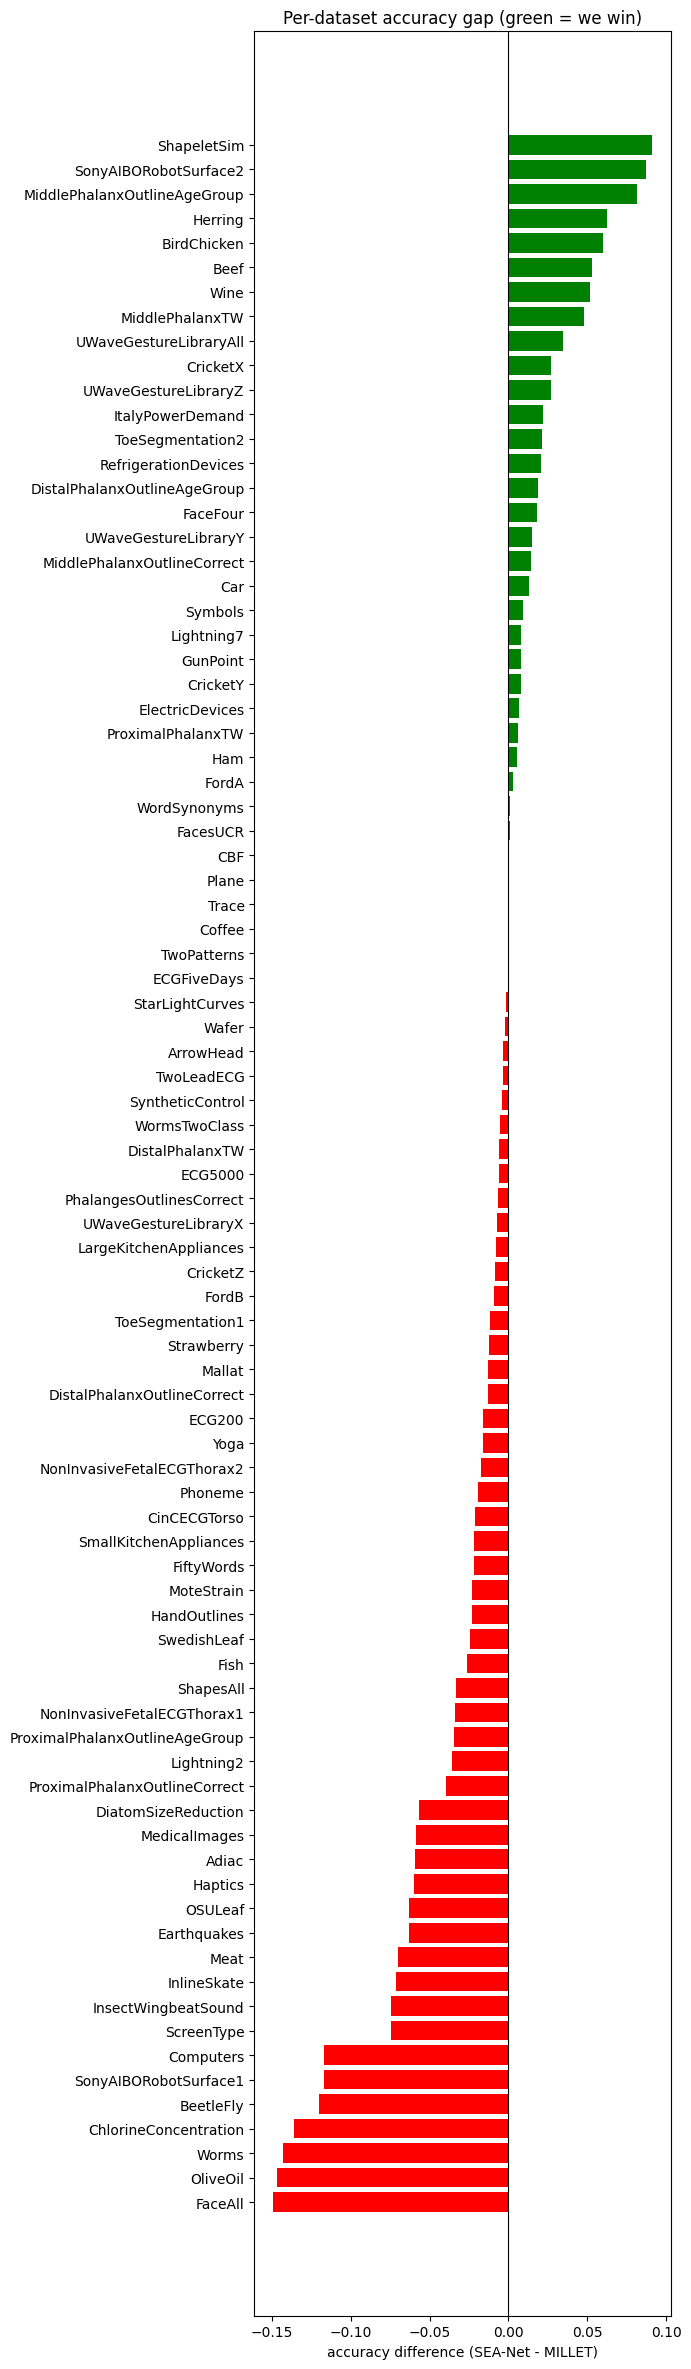

In [10]:
# Per-dataset accuracy gap (SEA-Net - MILLET), sorted
d = overlap.sort_values("acc_diff")
plt.figure(figsize=(7, max(3, 0.28 * len(d))))
plt.barh(d["dataset"], d["acc_diff"], color=["green" if v > 0 else "red" for v in d["acc_diff"]])
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("accuracy difference (SEA-Net - MILLET)")
plt.title("Per-dataset accuracy gap (green = we win)")
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, "acc_diff.png"), dpi=120)
plt.show()

## Notes

- **Accuracy** vs MILLET is shown by the first scatter, the win/tie/loss bar, and the per-dataset gap.
- **AOPCR** (interpretation faithfulness) is the second scatter. If most points sit below the line, SEA-Net's explanations are less faithful than MILLET's - worth improving.
- Only the ~85 overlap datasets have a MILLET number; the rest are SEA-Net-only (see `results.csv`).
- Re-run this notebook after more of the sweep finishes to refresh every figure.